# Neural Machine Translation with Cross-Attention
## English to Spanish Translation using Transformer-based Mechanisms

**Course:** Foundational Models and Generative AI


## 1. Import Required Libraries

In [ ]:
!pip install datasets -q

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import re
import string
from datasets import load_dataset

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load and Prepare the Dataset
I split this into:
- **Training**: 40,000 pairs (80%)
- **Validation**: 5,000 pairs (10%)
- **Test**: 5,000 pairs (10%)

In [ ]:
dataset = load_dataset("OscarNav/spa-eng", split="train")

dataset = dataset.select(range(min(50000, len(dataset))))

print(f"Total sentence pairs: {len(dataset)}")
print(f"\nSample pair:")
print(dataset[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/429 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.58M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/623k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/107067 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11897 [00:00<?, ? examples/s]

Total sentence pairs: 50000

Sample pair:
{'eng': 'When the curtain went up, the stage was dark.', 'spa': 'Al levantarse el telón, la escena estaba oscura.'}


In [ ]:
cols = dataset.column_names
print(f"Available columns: {cols}")

if 'en' in cols and 'es' in cols:
    en_col, es_col = 'en', 'es'
elif 'English' in cols and 'Spanish' in cols:
    en_col, es_col = 'English', 'Spanish'
elif 'english' in cols and 'spanish' in cols:
    en_col, es_col = 'english', 'spanish'
elif 'ENG' in cols and 'SPA' in cols:
    en_col, es_col = 'ENG', 'SPA'
elif 'translation' in cols:
    en_col, es_col = 'translation', 'translation'
else:
    en_col, es_col = cols[0], cols[1]
    print(f"Using columns: {en_col}, {es_col}")

if en_col == 'translation':
    english_sentences = [item['translation']['en'] for item in dataset]
    spanish_sentences = [item['translation']['es'] for item in dataset]
else:
    english_sentences = [item[en_col] for item in dataset]
    spanish_sentences = [item[es_col] for item in dataset]

np.random.seed(42)
indices = np.random.permutation(len(english_sentences))
english_sentences = [english_sentences[i] for i in indices]
spanish_sentences = [spanish_sentences[i] for i in indices]

train_size = 40000
val_size = 5000

eng_train = english_sentences[:train_size]
spa_train = spanish_sentences[:train_size]

eng_val = english_sentences[train_size:train_size + val_size]
spa_val = spanish_sentences[train_size:train_size + val_size]

eng_test = english_sentences[train_size + val_size:]
spa_test = spanish_sentences[train_size + val_size:]

print(f"\nTraining pairs:   {len(eng_train)}")
print(f"Validation pairs: {len(eng_val)}")
print(f"Test pairs:       {len(eng_test)}")

print("\n--- Sample Pairs (from training set) ---")
for i in range(5):
    print(f"  EN: {eng_train[i]}")
    print(f"  ES: {spa_train[i]}\n")

Available columns: ['eng', 'spa']
Using columns: eng, spa

Training pairs:   40000
Validation pairs: 5000
Test pairs:       5000

--- Sample Pairs (from training set) ---
  EN: Tom helped Mary clean the house.
  ES: Tom le ayudó a Mary a limpiar la casa.

  EN: I think you need to buy a new pair of hiking boots.
  ES: Creo que debes comprarte un nuevo par de botas de alpinismo.

  EN: Her mother is not as old as she looks.
  ES: La madre de ella no es tan mayor como aparenta.

  EN: That book is a new book.
  ES: Ese libro es un libro nuevo.

  EN: This is too hard.
  ES: Esto es demasiado duro.



## 3. Text Standardization and Tokenization (Task 1)

In [ ]:
def standardize_text(text):
    "Convert to lowercase and remove punctuation."
    text = text.lower().strip()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def add_start_end_tokens(text):
    "Prepend [start] and append [end] to a sentence."
    text = standardize_text(text)
    return f"[start] {text} [end]"


eng_train_clean = [standardize_text(s) for s in eng_train]
spa_train_clean = [add_start_end_tokens(s) for s in spa_train]

eng_val_clean = [standardize_text(s) for s in eng_val]
spa_val_clean = [add_start_end_tokens(s) for s in spa_val]

eng_test_clean = [standardize_text(s) for s in eng_test]
spa_test_clean = [add_start_end_tokens(s) for s in spa_test]

print("--- Cleaned Samples ---")
for i in range(3):
    print(f"  EN: {eng_train_clean[i]}")
    print(f"  ES: {spa_train_clean[i]}\n")

--- Cleaned Samples ---
  EN: tom helped mary clean the house
  ES: [start] tom le ayudó a mary a limpiar la casa [end]

  EN: i think you need to buy a new pair of hiking boots
  ES: [start] creo que debes comprarte un nuevo par de botas de alpinismo [end]

  EN: her mother is not as old as she looks
  ES: [start] la madre de ella no es tan mayor como aparenta [end]



## 4. Build Vocabulary and Sequence Pipelines

In [ ]:
MAX_VOCAB_SIZE = 15000
MAX_SEQ_LENGTH = 20


def custom_standardization(input_string):
    "Custom standardization for TextVectorization — keeps [start] and [end]."
    lowercase = tf.strings.lower(input_string)
    stripped = tf.strings.regex_replace(lowercase, r"[^\w\s\[\]]", "")
    return stripped


eng_vectorizer = layers.TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_SEQ_LENGTH,
    standardize=custom_standardization,
)

spa_vectorizer = layers.TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_SEQ_LENGTH + 1,
    standardize=custom_standardization,
)

eng_vectorizer.adapt(eng_train_clean)
spa_vectorizer.adapt(spa_train_clean)

eng_vocab = eng_vectorizer.get_vocabulary()
spa_vocab = spa_vectorizer.get_vocabulary()
print(f"English vocabulary size: {len(eng_vocab)}")
print(f"Spanish vocabulary size: {len(spa_vocab)}")

start_idx = spa_vocab.index("[start]") if "[start]" in spa_vocab else "NOT FOUND"
end_idx = spa_vocab.index("[end]") if "[end]" in spa_vocab else "NOT FOUND"
print(f"\n'[start]' index: {start_idx}")
print(f"'[end]' index: {end_idx}")

sample_eng = eng_vectorizer(["i love cats"])
sample_spa = spa_vectorizer(["[start] me gustan los gatos [end]"])
print(f"\nSample English vectorized: {sample_eng.numpy()}")
print(f"Sample Spanish vectorized: {sample_spa.numpy()}")

English vocabulary size: 9141
Spanish vocabulary size: 15000

'[start]' index: 2
'[end]' index: 3

Sample English vectorized: [[  3 157 583   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]]
Sample Spanish vectorized: [[  2  14 252  21 581   3   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0]]


## 5. Create Training and Validation Datasets


In [ ]:
BATCH_SIZE = 64


def prepare_dataset(eng_texts, spa_texts):
    "Create a tf.data.Dataset from text pairs."
    eng_tensor = eng_vectorizer(eng_texts)
    spa_tensor = spa_vectorizer(spa_texts)

    spa_input = spa_tensor[:, :-1]
    spa_target = spa_tensor[:, 1:]

    dataset = tf.data.Dataset.from_tensor_slices(
        ((eng_tensor, spa_input), spa_target)
    )
    return dataset


train_ds = prepare_dataset(eng_train_clean, spa_train_clean)
val_ds = prepare_dataset(eng_val_clean, spa_val_clean)
test_ds = prepare_dataset(eng_test_clean, spa_test_clean)

train_ds = train_ds.shuffle(buffer_size=10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

for (eng_batch, spa_in_batch), spa_tgt_batch in train_ds.take(1):
    print(f"English input shape:         {eng_batch.shape}")
    print(f"Spanish decoder input shape: {spa_in_batch.shape}")
    print(f"Spanish target shape:        {spa_tgt_batch.shape}")

English input shape:         (64, 20)
Spanish decoder input shape: (64, 20)
Spanish target shape:        (64, 20)


## 6. Positional Embedding Layer

In [ ]:
D_MODEL = 256
NUM_HEADS = 4


class PositionalEmbedding(layers.Layer):
    "Combines token embedding with positional embedding."

    def __init__(self, vocab_size, seq_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.seq_length = seq_length
        self.vocab_size = vocab_size
        self.token_embedding = layers.Embedding(
            input_dim=vocab_size, output_dim=d_model
        )
        self.position_embedding = layers.Embedding(
            input_dim=seq_length, output_dim=d_model
        )

    def call(self, inputs):
        seq_length = tf.shape(inputs)[1]
        positions = tf.range(start=0, limit=seq_length, delta=1)
        token_emb = self.token_embedding(inputs)
        pos_emb = self.position_embedding(positions)
        return token_emb + pos_emb

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "seq_length": self.seq_length,
            "vocab_size": self.vocab_size,
        })
        return config

## 7. Multi-Head Cross-Attention Layer (Task 2)

This is the most important part of the assignment — the **Cross-Attention** mechanism that connects the two languages.

**How it works:**
- **Queries (Q)** come from the Spanish decoder sequence — these represent "what is the decoder looking for?"
- **Keys (K) and Values (V)** come from the English encoder output — these represent "what information does the source have?"
- Each decoder token computes attention scores against **all** encoder positions, so every generated Spanish word is contextually grounded in the full English input.

In [ ]:
class MultiHeadCrossAttention(layers.Layer):
    """
    Custom Multi-Head Cross-Attention layer.
    - Q is derived from the decoder (Spanish) sequence
    - K, V are derived from the encoder (English) output
    - Uses 4 attention heads with d_model=256
    """

    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.depth = d_model // num_heads

        self.wq = layers.Dense(d_model)
        self.wk = layers.Dense(d_model)
        self.wv = layers.Dense(d_model)

        self.wo = layers.Dense(d_model)

        self.layernorm = layers.LayerNormalization()
        self.add = layers.Add()

        self.last_attention_weights = None

    def split_heads(self, x, batch_size):
        "Split the last dimension into (num_heads, depth) and transpose."
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def scaled_dot_product_attention(self, q, k, v):
        """
        Compute scaled dot-product attention.
        Attention(Q, K, V) = softmax(Q @ K^T / sqrt(d_k)) @ V
        """
        matmul_qk = tf.matmul(q, k, transpose_b=True)

        dk = tf.cast(self.depth, tf.float32)
        scaled_scores = matmul_qk / tf.math.sqrt(dk)

        attention_weights = tf.nn.softmax(scaled_scores, axis=-1)

        output = tf.matmul(attention_weights, v)
        return output, attention_weights

    def call(self, decoder_sequence, encoder_output):
        """
        Forward pass.
        - decoder_sequence: Spanish decoder representations (batch, seq_spa, d_model)
        - encoder_output:   English encoder output (batch, seq_eng, d_model)
        """
        batch_size = tf.shape(decoder_sequence)[0]

        q = self.wq(decoder_sequence)
        k = self.wk(encoder_output)
        v = self.wv(encoder_output)

        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        attn_output, attention_weights = self.scaled_dot_product_attention(q, k, v)

        self.last_attention_weights = attention_weights

        attn_output = tf.transpose(attn_output, perm=[0, 2, 1, 3])
        attn_output = tf.reshape(attn_output, (batch_size, -1, self.d_model))

        output = self.wo(attn_output)

        output = self.add([decoder_sequence, output])
        output = self.layernorm(output)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "num_heads": self.num_heads,
        })
        return config

## 8. Build the Encoder (Task 3)


In [ ]:
class Encoder(layers.Layer):
    """
    Encoder block: processes English source into contextual representations.
    Self-Attention lets every English token attend to all other English tokens.
    """

    def __init__(self, vocab_size, seq_length, d_model, num_heads, ff_dim, **kwargs):
        super().__init__(**kwargs)
        self.pos_embedding = PositionalEmbedding(vocab_size, seq_length, d_model)

        self.self_attention = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads
        )
        self.layernorm1 = layers.LayerNormalization()

        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model),
        ])
        self.layernorm2 = layers.LayerNormalization()
        self.dropout1 = layers.Dropout(0.1)
        self.dropout2 = layers.Dropout(0.1)

    def call(self, inputs, training=False):
        x = self.pos_embedding(inputs)

        attn_output = self.self_attention(query=x, value=x, key=x)
        attn_output = self.dropout1(attn_output, training=training)
        x = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(x)
        ffn_output = self.dropout2(ffn_output, training=training)
        x = self.layernorm2(x + ffn_output)

        return x

## 9. Build the Decoder with Cross-Attention

In [ ]:
class Decoder(layers.Layer):
    """
    Decoder block: processes Spanish target with cross-attention to the encoder.
    - Causal Self-Attention: masked so decoder can't see future tokens
    - Cross-Attention: Q from decoder, K/V from encoder
    - Feed-Forward: dense layers
    """

    def __init__(self, vocab_size, seq_length, d_model, num_heads, ff_dim, **kwargs):
        super().__init__(**kwargs)
        self.pos_embedding = PositionalEmbedding(vocab_size, seq_length, d_model)

        self.self_attention = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads
        )
        self.layernorm1 = layers.LayerNormalization()

        self.cross_attention = MultiHeadCrossAttention(d_model, num_heads)

        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model),
        ])
        self.layernorm3 = layers.LayerNormalization()

        self.dropout1 = layers.Dropout(0.1)
        self.dropout2 = layers.Dropout(0.1)

    def call(self, inputs, encoder_output, training=False):
        x = self.pos_embedding(inputs)

        attn_output = self.self_attention(
            query=x, value=x, key=x, use_causal_mask=True
        )
        attn_output = self.dropout1(attn_output, training=training)
        x = self.layernorm1(x + attn_output)

        x = self.cross_attention(x, encoder_output)

        ffn_output = self.ffn(x)
        ffn_output = self.dropout2(ffn_output, training=training)
        x = self.layernorm3(x + ffn_output)

        return x

## 10. Assemble the Full Transformer Model

In [ ]:
class Transformer(keras.Model):
    "Full Encoder-Decoder Transformer for English to Spanish translation."

    def __init__(self, eng_vocab_size, spa_vocab_size, eng_seq_len, spa_seq_len,
                 d_model, num_heads, ff_dim, **kwargs):
        super().__init__(**kwargs)

        self.encoder = Encoder(eng_vocab_size, eng_seq_len, d_model, num_heads, ff_dim)
        self.decoder = Decoder(spa_vocab_size, spa_seq_len, d_model, num_heads, ff_dim)

        self.final_layer = layers.Dense(spa_vocab_size, activation="softmax")

    def call(self, inputs, training=False):
        eng_input, spa_input = inputs

        encoder_output = self.encoder(eng_input, training=training)

        decoder_output = self.decoder(spa_input, encoder_output, training=training)

        output = self.final_layer(decoder_output)
        return output


ENG_VOCAB_SIZE = len(eng_vectorizer.get_vocabulary())
SPA_VOCAB_SIZE = len(spa_vectorizer.get_vocabulary())
ENG_SEQ_LEN = MAX_SEQ_LENGTH
SPA_SEQ_LEN = MAX_SEQ_LENGTH
FF_DIM = 512

model = Transformer(
    eng_vocab_size=ENG_VOCAB_SIZE,
    spa_vocab_size=SPA_VOCAB_SIZE,
    eng_seq_len=ENG_SEQ_LEN,
    spa_seq_len=SPA_SEQ_LEN,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
)

for (eng_batch, spa_in_batch), spa_tgt_batch in train_ds.take(1):
    sample_output = model((eng_batch, spa_in_batch))
    print(f"Model output shape: {sample_output.shape}")

model.summary()

Model output shape: (64, 20, 15000)


Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Encoder)               │ ?                      │     2,872,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Decoder)               │ ?                      │     4,635,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (64, 20, 15000)        │     3,855,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,363,224 (43.35 MB)

 Trainable params: 11,363,224 (43.35 MB)

 Non-trainable params: 0 (0.00 B)

## 11. Compile and Train the Model (Task 4)

I train for exactly **20 epochs** as specified.

In [ ]:
loss_fn = keras.losses.SparseCategoricalCrossentropy(reduction='none')


def masked_loss(y_true, y_pred):
    "Compute loss ignoring padding positions (token index 0)."
    mask = tf.math.not_equal(y_true, 0)
    loss = loss_fn(y_true, y_pred)
    mask = tf.cast(mask, dtype=loss.dtype)
    loss *= mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)


def masked_accuracy(y_true, y_pred):
    "Compute accuracy ignoring padding positions."
    mask = tf.math.not_equal(y_true, 0)
    pred_ids = tf.argmax(y_pred, axis=-1)
    pred_ids = tf.cast(pred_ids, y_true.dtype)
    matches = tf.equal(y_true, pred_ids)
    matches = tf.cast(matches, dtype=tf.float32)
    mask = tf.cast(mask, dtype=tf.float32)
    return tf.reduce_sum(matches * mask) / tf.reduce_sum(mask)


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=masked_loss,
    metrics=[masked_accuracy],
)

print("Model compiled successfully. Ready to train.")

Model compiled successfully. Ready to train.


In [ ]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

print("\nTraining complete!")

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 35ms/step - loss: 5.0576 - masked_accuracy: 0.3113 - val_loss: 2.5961 - val_masked_accuracy: 0.5695
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - loss: 2.1200 - masked_accuracy: 0.6183 - val_loss: 2.1835 - val_masked_accuracy: 0.6196
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - loss: 1.2866 - masked_accuracy: 0.7160 - val_loss: 2.1220 - val_masked_accuracy: 0.6304
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - loss: 0.8764 - masked_accuracy: 0.7806 - val_loss: 2.2005 - val_masked_accuracy: 0.6301
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - loss: 0.6800 - masked_accuracy: 0.8198 - val_loss: 2.2084 - val_masked_accuracy: 0.6351
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - loss: 0.5593 - masked_accuracy: 0.8498 - val_loss: 2.2818 - val_masked_accuracy: 0.6311
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - loss: 0.4778 - masked_accuracy: 0.8684 - val_loss: 2.3985 - val_masked_accuracy:

## 12. Training Loss vs. Validation Loss


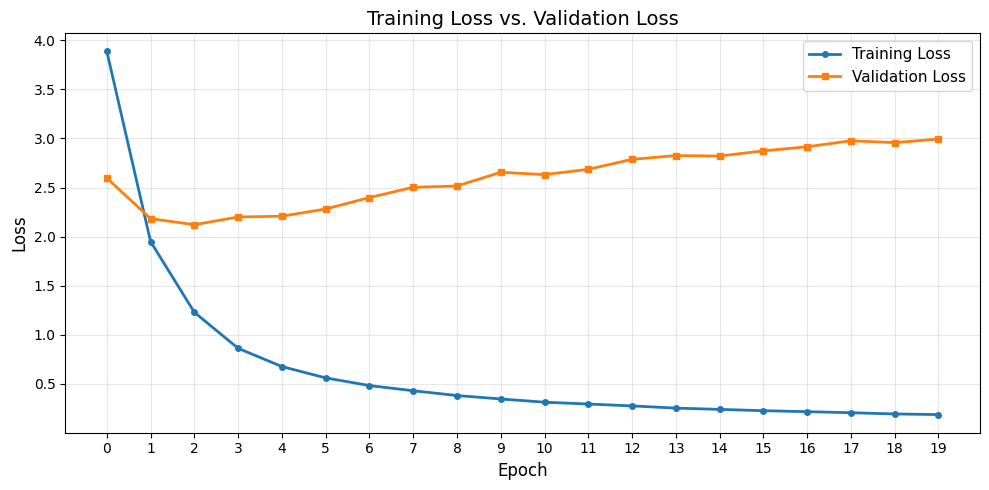

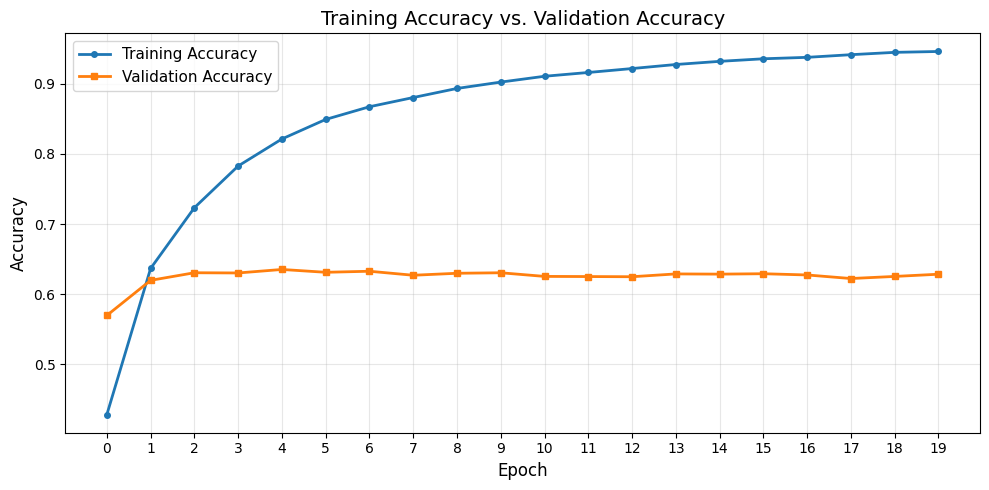

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2, marker='o', markersize=4)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, marker='s', markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss vs. Validation Loss', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, EPOCHS))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history['masked_accuracy'], label='Training Accuracy', linewidth=2, marker='o', markersize=4)
plt.plot(history.history['val_masked_accuracy'], label='Validation Accuracy', linewidth=2, marker='s', markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training Accuracy vs. Validation Accuracy', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, EPOCHS))
plt.tight_layout()
plt.show()

## 13. Greedy Inference for Translation (Task 4)

In [ ]:
spa_vocab = spa_vectorizer.get_vocabulary()
spa_index_to_word = {i: word for i, word in enumerate(spa_vocab)}

start_token_index = spa_vocab.index("[start]")
end_token_index = spa_vocab.index("[end]")

print(f"[start] token index: {start_token_index}")
print(f"[end] token index: {end_token_index}")


def translate(input_sentence):
    """
    Translate an English sentence to Spanish using greedy decoding.

    Steps:
    1. Standardize and vectorize the English input
    2. Start decoder with [start] token
    3. Predict next word greedily (argmax) at each step
    4. Stop at [end] or max length
    """
    cleaned = standardize_text(input_sentence)
    eng_tokens = eng_vectorizer([cleaned])

    decoder_input = [start_token_index]

    for i in range(MAX_SEQ_LENGTH):
        padded_input = tf.keras.preprocessing.sequence.pad_sequences(
            [decoder_input], maxlen=MAX_SEQ_LENGTH, padding="post"
        )
        padded_input = tf.cast(padded_input, dtype=tf.int64)

        predictions = model((eng_tokens, padded_input), training=False)

        next_token_probs = predictions[0, len(decoder_input) - 1, :]
        next_token_id = tf.argmax(next_token_probs).numpy()

        if next_token_id == end_token_index:
            break

        if next_token_id == 0:
            break

        decoder_input.append(int(next_token_id))

    translated_words = []
    for idx in decoder_input[1:]:
        word = spa_index_to_word.get(idx, "")
        if word and word != "[end]":
            translated_words.append(word)

    return " ".join(translated_words)


print("Quick test translations:")
test_phrases = ["hello", "thank you", "i love you"]
for phrase in test_phrases:
    print(f"  EN: {phrase}  ->  ES: {translate(phrase)}")

[start] token index: 2
[end] token index: 3
Quick test translations:
  EN: hello  ->  ES: hola
  EN: thank you  ->  ES: gracias a ti
  EN: i love you  ->  ES: te quiero


## 14. Translation Samples on Test Data

In [ ]:
print("=" * 70)
print("         TRANSLATION SAMPLES FROM TEST SET")
print("=" * 70)

test_indices = [0, 100, 500, 1000, 2000]

for idx in test_indices:
    if idx < len(eng_test):
        eng_sentence = eng_test[idx]
        spa_sentence = spa_test[idx]
        prediction = translate(eng_sentence)

        example_num = test_indices.index(idx) + 1
        print(f"\n--- Example {example_num} ---")
        print(f"  Source (English):    {eng_sentence}")
        print(f"  Target (Spanish):    {spa_sentence}")
        print(f"  Model Prediction:    {prediction}")
        print()

print("=" * 70)

         TRANSLATION SAMPLES FROM TEST SET

--- Example 1 ---
  Source (English):    They held hands.
  Target (Spanish):    Ellos se tomaron de la mano.
  Model Prediction:    ellos las manos


--- Example 2 ---
  Source (English):    The boy over there is bowing to you.
  Target (Spanish):    Aquel chico de allí se está inclinando ante ti.
  Model Prediction:    el chico all est ms que te levantes


--- Example 3 ---
  Source (English):    I can't tell you how much your support means to us.
  Target (Spanish):    No puedo expresarte cuánto significa tu apoyo para nosotros.
  Model Prediction:    no puedo decir cunto te parece mucho no te concierne


--- Example 4 ---
  Source (English):    This room is pleasant to work in.
  Target (Spanish):    Esta pieza es agradable para trabajar.
  Model Prediction:    esta habitacin est agradable en trabajar


--- Example 5 ---
  Source (English):    We decided not to have peace negotiations with the invaders.
  Target (Spanish):    Nosotros dec

## 15. Quantitative Evaluation: BLEU Scores on Test Set

Translating 500 test sentences for BLEU evaluation...
  Translated 100/500...
  Translated 200/500...
  Translated 300/500...
  Translated 400/500...
  Translated 500/500...

  BLEU Score Results (500 test sentences)
  BLEU-1 (unigram):    0.5055
  BLEU-2 (bigram):     0.3721
  BLEU-4 (4-gram):     0.1992
  Mean sentence BLEU:  0.1952
  Median sentence BLEU:0.1015


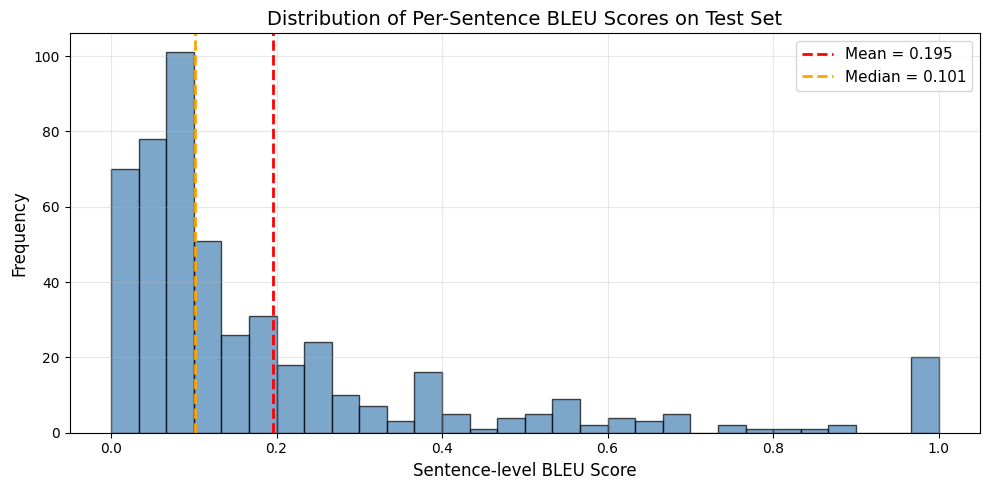

In [ ]:
!pip install nltk -q

import nltk
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

NUM_EVAL = 500
smoothing = SmoothingFunction().method1

references_corpus = []
hypotheses_corpus = []
sentence_bleu_scores = []

print(f"Translating {NUM_EVAL} test sentences for BLEU evaluation...")
for i in range(min(NUM_EVAL, len(eng_test))):
    ref_text = standardize_text(spa_test[i])
    ref_tokens = ref_text.split()

    hyp_text = translate(eng_test[i])
    hyp_tokens = hyp_text.split()

    references_corpus.append([ref_tokens])
    hypotheses_corpus.append(hyp_tokens)

    s_bleu = sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoothing)
    sentence_bleu_scores.append(s_bleu)

    if (i + 1) % 100 == 0:
        print(f"  Translated {i + 1}/{NUM_EVAL}...")

bleu_1 = corpus_bleu(references_corpus, hypotheses_corpus, weights=(1, 0, 0, 0))
bleu_2 = corpus_bleu(references_corpus, hypotheses_corpus, weights=(0.5, 0.5, 0, 0))
bleu_4 = corpus_bleu(references_corpus, hypotheses_corpus, weights=(0.25, 0.25, 0.25, 0.25))

print(f"\n{'='*50}")
print(f"  BLEU Score Results ({NUM_EVAL} test sentences)")
print(f"{'='*50}")
print(f"  BLEU-1 (unigram):    {bleu_1:.4f}")
print(f"  BLEU-2 (bigram):     {bleu_2:.4f}")
print(f"  BLEU-4 (4-gram):     {bleu_4:.4f}")
print(f"  Mean sentence BLEU:  {np.mean(sentence_bleu_scores):.4f}")
print(f"  Median sentence BLEU:{np.median(sentence_bleu_scores):.4f}")
print(f"{'='*50}")

plt.figure(figsize=(10, 5))
plt.hist(sentence_bleu_scores, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(np.mean(sentence_bleu_scores), color='red', linestyle='--', linewidth=2,
            label=f'Mean = {np.mean(sentence_bleu_scores):.3f}')
plt.axvline(np.median(sentence_bleu_scores), color='orange', linestyle='--', linewidth=2,
            label=f'Median = {np.median(sentence_bleu_scores):.3f}')
plt.xlabel('Sentence-level BLEU Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Per-Sentence BLEU Scores on Test Set', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 16. Cross-Attention Weight Visualization


EN: I love cats  →  ES: me encanta gatos


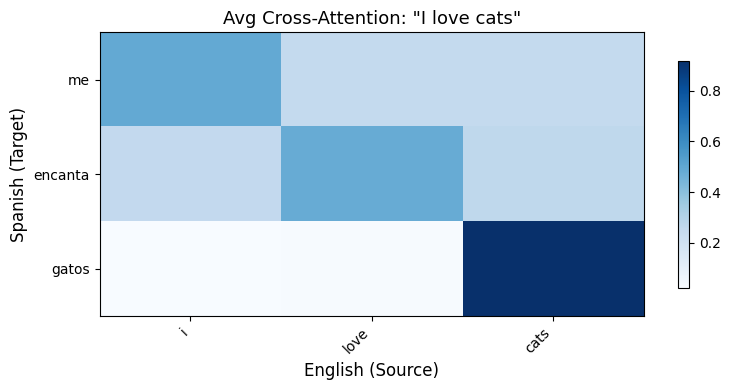

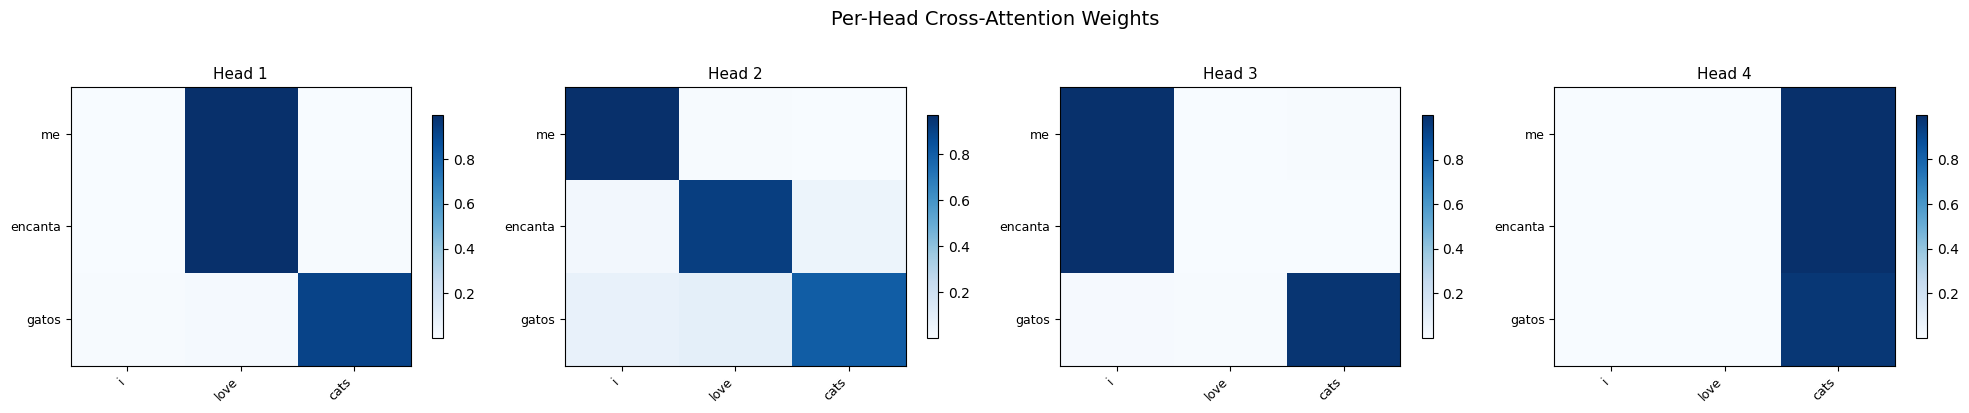


EN: The weather is good today  →  ES: hoy el tiempo es bueno


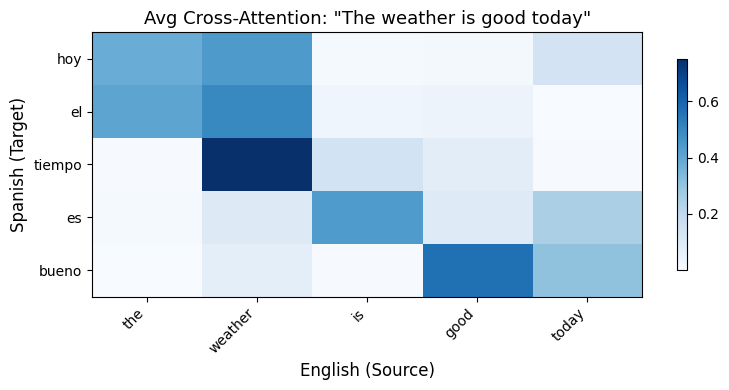

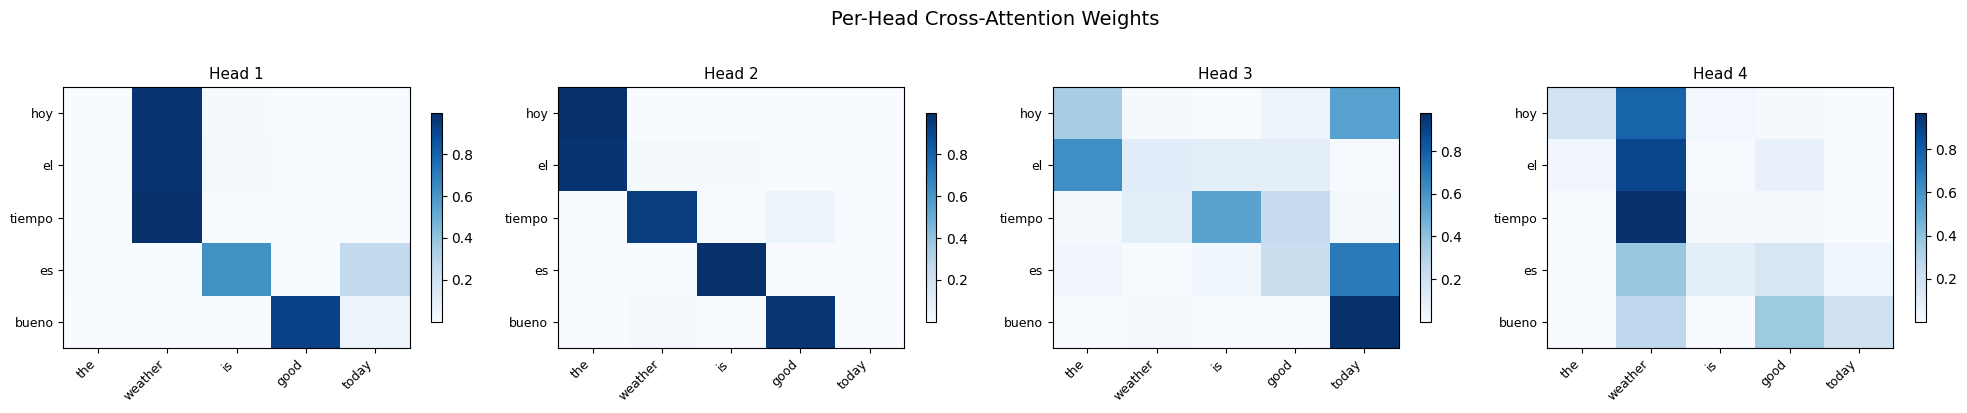


EN: She is my best friend  →  ES: es mi mejor amiga


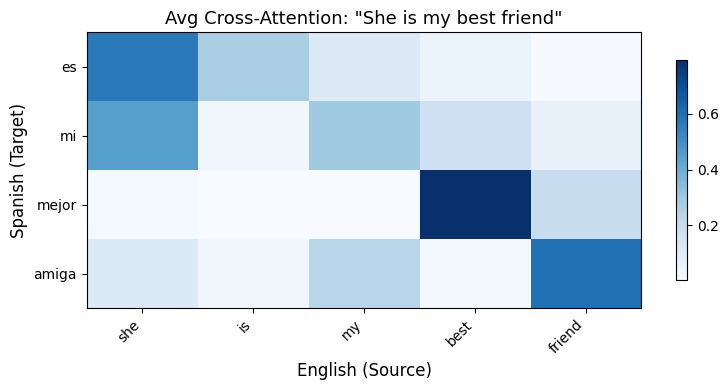

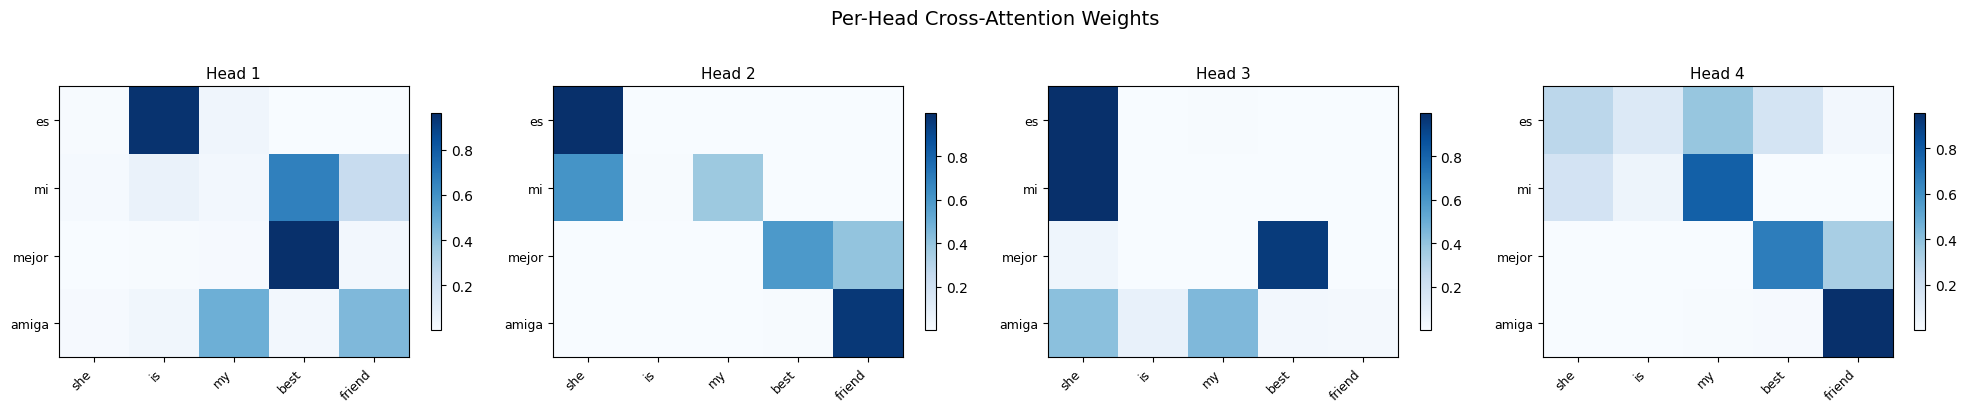

In [ ]:
def get_attention_weights_and_translate(input_sentence):
    """
    Translate an English sentence and return the cross-attention weights
    along with the source/target tokens for visualization.
    """
    cleaned = standardize_text(input_sentence)
    eng_tokens = eng_vectorizer([cleaned])

    eng_vocab = eng_vectorizer.get_vocabulary()
    eng_token_ids = eng_tokens.numpy()[0]
    eng_words = [eng_vocab[idx] if idx < len(eng_vocab) else "" for idx in eng_token_ids]
    eng_words = [w for w in eng_words if w and w != ""]
    eng_nonpad_len = len(eng_words)

    decoder_input = [start_token_index]
    spa_words = []

    for i in range(MAX_SEQ_LENGTH):
        padded_input = tf.keras.preprocessing.sequence.pad_sequences(
            [decoder_input], maxlen=MAX_SEQ_LENGTH, padding="post"
        )
        padded_input = tf.cast(padded_input, dtype=tf.int64)

        predictions = model((eng_tokens, padded_input), training=False)

        next_token_probs = predictions[0, len(decoder_input) - 1, :]
        next_token_id = tf.argmax(next_token_probs).numpy()

        if next_token_id == end_token_index or next_token_id == 0:
            break

        decoder_input.append(int(next_token_id))
        spa_words.append(spa_index_to_word.get(int(next_token_id), ""))

    attn_weights = model.decoder.cross_attention.last_attention_weights.numpy()

    avg_attn = np.mean(attn_weights[0], axis=0)

    spa_len = len(spa_words)
    avg_attn_trimmed = avg_attn[:spa_len, :eng_nonpad_len]

    return eng_words[:eng_nonpad_len], spa_words, avg_attn_trimmed, attn_weights[0]


def plot_attention_heatmap(eng_words, spa_words, attention, title="Cross-Attention Weights"):
    """Plot a heatmap of attention weights between source and target tokens."""
    fig, ax = plt.subplots(figsize=(max(8, len(eng_words) * 0.8), max(4, len(spa_words) * 0.6)))
    im = ax.imshow(attention, cmap='Blues', aspect='auto')

    ax.set_xticks(range(len(eng_words)))
    ax.set_xticklabels(eng_words, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(len(spa_words)))
    ax.set_yticklabels(spa_words, fontsize=10)

    ax.set_xlabel('English (Source)', fontsize=12)
    ax.set_ylabel('Spanish (Target)', fontsize=12)
    ax.set_title(title, fontsize=13)

    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()


def plot_per_head_attention(eng_words, spa_words, attn_all_heads):
    """Plot attention weights for each head separately."""
    num_heads = attn_all_heads.shape[0]
    spa_len = len(spa_words)
    eng_len = len(eng_words)

    fig, axes = plt.subplots(1, num_heads, figsize=(5 * num_heads, max(4, spa_len * 0.5)))
    if num_heads == 1:
        axes = [axes]

    for h in range(num_heads):
        attn_h = attn_all_heads[h, :spa_len, :eng_len]
        im = axes[h].imshow(attn_h, cmap='Blues', aspect='auto')
        axes[h].set_xticks(range(eng_len))
        axes[h].set_xticklabels(eng_words, rotation=45, ha='right', fontsize=9)
        axes[h].set_yticks(range(spa_len))
        axes[h].set_yticklabels(spa_words, fontsize=9)
        axes[h].set_title(f'Head {h + 1}', fontsize=11)
        plt.colorbar(im, ax=axes[h], shrink=0.8)

    fig.suptitle('Per-Head Cross-Attention Weights', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


visualization_sentences = [
    "I love cats",
    "The weather is good today",
    "She is my best friend",
]

for sentence in visualization_sentences:
    eng_words, spa_words, avg_attn, all_heads_attn = get_attention_weights_and_translate(sentence)
    prediction = " ".join(spa_words)
    print(f"\nEN: {sentence}  →  ES: {prediction}")

    if len(spa_words) > 0 and len(eng_words) > 0:
        plot_attention_heatmap(eng_words, spa_words, avg_attn,
                               title=f'Avg Cross-Attention: "{sentence}"')
        plot_per_head_attention(eng_words, spa_words, all_heads_attn)
    else:
        print("  (Model produced empty output — skipping visualization)")

## 17. Failure Analysis and Error Categorization

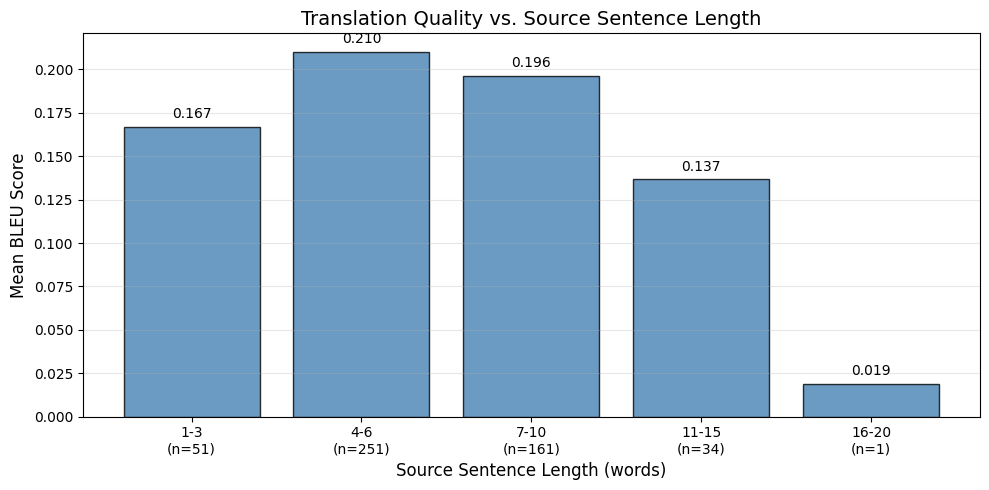


         ERROR CATEGORIZATION ANALYSIS

  High quality (BLEU >= 0.8):    24 (4.8%)
  Partial match (0.3 <= BLEU < 0.8): 67 (13.4%)
  Poor match (BLEU < 0.3):       409 (81.8%)
  Empty outputs:                  0 (0.0%)
  Repetition errors:              0 (0.0%)

--- Worst Translation Examples (lowest BLEU) ---
  EN:  I was out all day.
  REF: estuve afuera todo el día
  HYP: sal al da entero
  BLEU: 0.0000

  EN:  Tom is coming.
  REF: tomás está viniendo
  HYP: tom viene
  BLEU: 0.0000

  EN:  Do you have any ideas on how we can settle this matter?
  REF: se te ocurre alguna idea de cómo resolver este asunto
  HYP: tienes ideas distintas en adelante
  BLEU: 0.0000

  EN:  My jeans shrank in the wash.
  REF: mis vaqueros se encogieron con el lavado
  HYP: mi disco est todava en lavara
  BLEU: 0.0000

  EN:  Come forward.
  REF: acércate
  HYP: espera impaciente
  BLEU: 0.0000



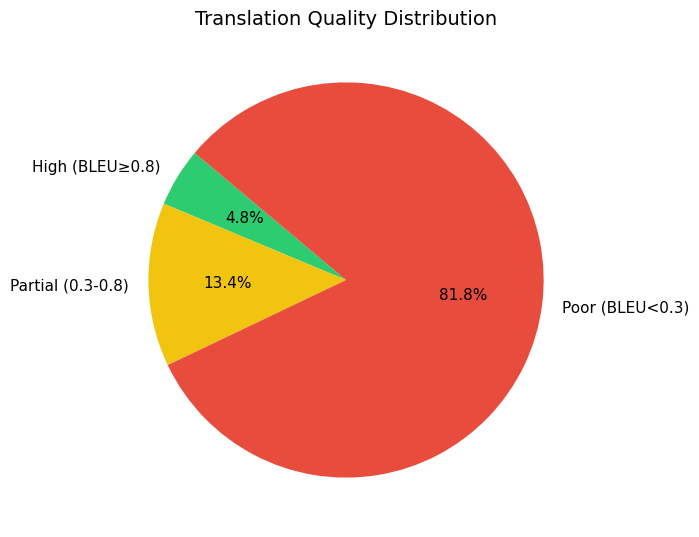

In [ ]:
from collections import Counter

NUM_ANALYSIS = 500

lengths = []
bleus_by_length = []

for i in range(min(NUM_ANALYSIS, len(eng_test))):
    src_len = len(standardize_text(eng_test[i]).split())
    lengths.append(src_len)
    bleus_by_length.append(sentence_bleu_scores[i])

bins = [(1, 3), (4, 6), (7, 10), (11, 15), (16, 20)]
bin_labels = []
bin_bleus = []

for lo, hi in bins:
    scores = [b for l, b in zip(lengths, bleus_by_length) if lo <= l <= hi]
    if scores:
        bin_labels.append(f"{lo}-{hi}\n(n={len(scores)})")
        bin_bleus.append(np.mean(scores))
    else:
        bin_labels.append(f"{lo}-{hi}\n(n=0)")
        bin_bleus.append(0)

plt.figure(figsize=(10, 5))
bars = plt.bar(bin_labels, bin_bleus, color='steelblue', edgecolor='black', alpha=0.8)
for bar, val in zip(bars, bin_bleus):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=10)
plt.xlabel('Source Sentence Length (words)', fontsize=12)
plt.ylabel('Mean BLEU Score', fontsize=12)
plt.title('Translation Quality vs. Source Sentence Length', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("         ERROR CATEGORIZATION ANALYSIS")
print("=" * 60)

exact_match = 0
partial_match = 0
no_match = 0
empty_output = 0
repetition_errors = 0

worst_examples = []

for i in range(min(NUM_ANALYSIS, len(eng_test))):
    ref = standardize_text(spa_test[i])
    hyp = " ".join(hypotheses_corpus[i])

    if not hyp.strip():
        empty_output += 1
        continue

    words = hyp.split()
    has_repetition = False
    for j in range(len(words) - 2):
        if words[j] == words[j + 1] == words[j + 2]:
            has_repetition = True
            break
    if has_repetition:
        repetition_errors += 1

    bleu = sentence_bleu_scores[i]
    if bleu >= 0.8:
        exact_match += 1
    elif bleu >= 0.3:
        partial_match += 1
    else:
        no_match += 1
        if bleu < 0.15:
            worst_examples.append((eng_test[i], ref, hyp, bleu))

worst_examples.sort(key=lambda x: x[3])

print(f"\n  High quality (BLEU >= 0.8):    {exact_match} ({exact_match / NUM_ANALYSIS * 100:.1f}%)")
print(f"  Partial match (0.3 <= BLEU < 0.8): {partial_match} ({partial_match / NUM_ANALYSIS * 100:.1f}%)")
print(f"  Poor match (BLEU < 0.3):       {no_match} ({no_match / NUM_ANALYSIS * 100:.1f}%)")
print(f"  Empty outputs:                  {empty_output} ({empty_output / NUM_ANALYSIS * 100:.1f}%)")
print(f"  Repetition errors:              {repetition_errors} ({repetition_errors / NUM_ANALYSIS * 100:.1f}%)")

print(f"\n--- Worst Translation Examples (lowest BLEU) ---")
for eng, ref, hyp, bleu in worst_examples[:5]:
    print(f"  EN:  {eng}")
    print(f"  REF: {ref}")
    print(f"  HYP: {hyp}")
    print(f"  BLEU: {bleu:.4f}")
    print()

labels_pie = ['High (BLEU≥0.8)', 'Partial (0.3-0.8)', 'Poor (BLEU<0.3)', 'Empty']
sizes = [exact_match, partial_match, no_match, empty_output]
colors = ['#2ecc71', '#f1c40f', '#e74c3c', '#95a5a6']
filtered = [(l, s, c) for l, s, c in zip(labels_pie, sizes, colors) if s > 0]
if filtered:
    labels_f, sizes_f, colors_f = zip(*filtered)
    plt.figure(figsize=(7, 7))
    plt.pie(sizes_f, labels=labels_f, autopct='%1.1f%%', colors=colors_f,
            startangle=140, textprops={'fontsize': 11})
    plt.title('Translation Quality Distribution', fontsize=14)
    plt.tight_layout()
    plt.show()

print("=" * 60)

## 18. Brief Analysis: Self-Attention vs. Cross-Attention

In Transformer based translation models, **Self-Attention** and **Cross-Attention** play different but supportive roles, both are very important for correct translation.

**Self-Attention** works inside a single sequence, where Queries, Keys and Values come from the same input. In the **encoder**, it allows each English word to look at other English words, helping the model understand relations like subject verb agreement, references (like what “it” means), and long distance dependencies. Without this, words would be processed alone and context will be lost. In the **decoder**, causal self-attention helps each Spanish word attend only to the previously generated words, keeping the sentence meaningful and grammatically correct.

**Cross-Attention** connects the encoder and decoder. Here, Queries come from the decoder (Spanish) and Keys/Values come from the encoder (English). This allows the decoder to focus on relevant English words while generating each Spanish word. For example, while generating “gato”, the model gives higher attention to the English word “cat”, showing proper alignment between source and target.

Both are required because:

1. **Self-attention** helps in understanding structure within the same language
2. **Cross-attention** helps in mapping words across languages

If self-attention is missing, the model cannot understand the sentence properly. If cross-attention is missing, the decoder cannot see the source sentence at all. Hence, both together make neural machine translation possible.

## 19. Translating English Poems to Spanish

As a fun demonstration, let's see how NMT model handles translating well-known English nursery rhymes — **"Jack and Jill"** and **"Johnny Johnny Yes Papa"** — line by line into Spanish.

In [ ]:
jack_and_jill = [
    "Jack and Jill went up the hill,",
    "To fetch a pail of water;",
    "Jack fell down, and broke his crown,",
    "And Jill came tumbling after.",
    "Up Jack got, and home did trot,",
    "As fast as he could caper,",
    "To old Dame Dob, who patched his nob,",
    "With vinegar and brown paper.",
]

johnny_johnny = [
    "Johny, Johny?",
    "Yes, Papa?",
    "Eating sugar?",
    "No, papa!",
    "Telling lies?",
    "No, papa!",
    "Open your mouth!",
    "Ha, ha, ha!",
]

def translate_poem(lines, title):
    """Translate a poem line by line and display side by side."""
    print("=" * 70)
    print(f"  {title}")
    print("=" * 70)
    print(f"  {'ENGLISH':<35} {'SPANISH (Model Translation)'}")
    print("-" * 70)
    for line in lines:
        spanish = translate(line)
        print(f"  {line:<35} {spanish}")
    print("=" * 70)
    print()

translate_poem(jack_and_jill, "POEM 1: Jack and Jill")
translate_poem(johnny_johnny, "POEM 2: Johnny Johnny Yes Papa")

  POEM 1: Jack and Jill
  ENGLISH                             SPANISH (Model Translation)
----------------------------------------------------------------------
  Jack and Jill went up the hill,     se requieren medidas inmediatas la colina
  To fetch a pail of water;           a traer algo de agua
  Jack fell down, and broke his crown, la rompiste y se rompi la copa
  And Jill came tumbling after.       y mara se declar la mitad de la suerte
  Up Jack got, and home did trot,     se puso la casa y se puso la escuela
  As fast as he could caper,          tan rpido como l podra ser separados
  To old Dame Dob, who patched his nob, a los anciano les resulten [UNK] a la figura
  With vinegar and brown paper.       con vinagre y papel quieto

  POEM 2: Johnny Johnny Yes Papa
  ENGLISH                             SPANISH (Model Translation)
----------------------------------------------------------------------
  Johny, Johny?                       sigue siendo un bonito
  Yes, Papa?         